# Membaca keseluruhan dataSet 

**Dataset utama**
1. `GDSC_DATASET.csv` : respons obat (`LN_IC50`, `AUC`, `Z_SCORE`) dan metadata *cell line* kanker.
2. `CCLE_RNAseq_rsem_genes_tpm_20180929.txt.gz` : ekspresi gen (RNA-seq, nilai TPM) untuk 1.019 *cell line*.

**Dataset pendukung:** `GDSC2-dataset.csv`, `Compounds-annotation.csv`, dan `Cell_Lines_Details.xlsx`. Isinya sebagian besar sudah tercakup dalam `GDSC_DATASET.csv`, sehingga dipakai sebagai anotasi dan cadangan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

gdsc2 = pd.read_csv("GDSC2-dataset.csv")
gdsc = pd.read_csv("GDSC_DATASET.csv")
comp = pd.read_csv("Compounds-annotation.csv")
cells = pd.read_excel("Cell_Lines_Details.xlsx", sheet_name="Cell line details")
expr = pd.read_csv("CCLE_RNAseq_rsem_genes_tpm_20180929.txt.gz", sep="\t")

display(gdsc.head()) #menampilkan data
display(comp.head()) #menampilkan data
display(cells.head()) #menampilkan data
display(expr.iloc[:5, :5]) #menampilkan data hanya 5 kolom pertama

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


,DRUG_ID,SCREENING_SITE,DRUG_NAME,SYNONYMS,TARGET,TARGET_PATHWAY
0,1,MGH,Erlotinib,"Tarceva, RG-1415, CP-358774, OSI-774, Ro-50823...",EGFR,EGFR signaling
1,3,MGH,Rapamycin,"AY-22989, Sirolimus, WY-090217, Torisel, Rapamune",MTORC1,PI3K/MTOR signaling
2,5,MGH,Sunitinib,"Sutent, Sunitinib Malate, SU-11248","PDGFR, KIT, VEGFR, FLT3, RET, CSF1R",RTK signaling
3,6,MGH,PHA-665752,"PHA665752, PHA 665752",MET,RTK signaling
4,9,MGH,MG-132,"LLL cpd, MG 132, MG132","Proteasome, CAPN1",Protein stability and degradation


,Sample Name,COSMIC identifier,Whole Exome Sequencing (WES),Copy Number Alterations (CNA),Gene Expression,Methylation,Drug\nResponse,GDSC\nTissue descriptor 1,GDSC\nTissue\ndescriptor 2,Cancer Type\n(matching TCGA label),Microsatellite \ninstability Status (MSI),Screen Medium,Growth Properties
0,A253,906794.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,NaN,MSS/MSI-L,D/F12,Adherent
1,BB30-HNC,753531.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
2,BB49-HNC,753532.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
3,BHY,753535.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
4,BICR10,1290724.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent


,gene_id,transcript_ids,22RV1_PROSTATE,2313287_STOMACH,253JBV_URINARY_TRACT
0,ENSG00000000003.10,"ENST00000373020.4,ENST00000494424.1,ENST000004...",5.28,7.01,22.80
1,ENSG00000000005.5,"ENST00000373031.4,ENST00000485971.1",0.00,0.00,0.00
2,ENSG00000000419.8,"ENST00000371582.4,ENST00000371583.5,ENST000003...",73.38,108.99,56.51
3,ENSG00000000457.9,"ENST00000367770.1,ENST00000367771.6,ENST000003...",9.76,16.76,2.58
4,ENSG00000000460.12,"ENST00000286031.6,ENST00000359326.4,ENST000004...",24.51,13.32,10.86


# Data Understanding

tahap ini hanya melihat dan mencatat data mulai dari ukuran, tipe, nilai kosong, statistik dasar, dan kategori. Belum ada data yang di ubah. Temuannya menjadi dasar untuk EDA dan rencana preprocessing. 

### pada dataset `GDSC_DATASET.csv` (respon obat)

**Isi Data**: satu baris berisi pengujian **satu obat pada satu *cell line*** (pasangan *cell line*-obat).

In [3]:
# lihat bentuk data
print(gdsc.shape) # melihat berapa total Baris dan kolom yang ada (242035, 19)
print("\n")
print(gdsc.columns) # melihat nama-nama kolom yang ada 
print("\n")
print(gdsc.dtypes) #mengecek kolom dengan tipe datanya
print("\n")

(242035, 19)


Index(['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME',
       'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1',
       'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)',
       'Microsatellite instability Status (MSI)', 'Screen Medium',
       'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET',
       'TARGET_PATHWAY'],
      dtype='object')


COSMIC_ID                                    int64
CELL_LINE_NAME                              object
TCGA_DESC                                   object
DRUG_ID                                      int64
DRUG_NAME                                   object
LN_IC50                                    float64
AUC                                        float64
Z_SCORE                                    float64
GDSC Tissue descriptor 1                    object
GDSC Tissue descriptor 2                    object
Cancer Type (matching TCGA label)           object
Microsatellite in

#### Struktur data

- Dataset ini memiliki **242035 baris dan 19 kolom**.
- Tipe data: **3 kolom** bertipe data `float64` (`LN_IC50`, `AUC`, `Z_SCORE`), **2 kolom** bertipe data `int64`(`COSMIC_ID`, `DRUG_ID`) dan **14 kolom** `object`(teks/kategori)
- `COSMIC_ID` dan `DRUG_ID` bertipe data angka hanya sebagai nomor identitas dan tidak ikut dalam hitungan statistiknya.
- variabel yang dianalisis berupa `LN_IC50`, `AUC` dan `Z_SCORE`. 
- variabel kategorikal: jaringan, jenis kanker, status MSI, sifat tumbuh, dan media.

In [4]:
print(gdsc.info()) # tipe data dan jumlah non-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242035 entries, 0 to 242034
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                242035 non-null  int64  
 1   CELL_LINE_NAME                           242035 non-null  object 
 2   TCGA_DESC                                240968 non-null  object 
 3   DRUG_ID                                  242035 non-null  int64  
 4   DRUG_NAME                                242035 non-null  object 
 5   LN_IC50                                  242035 non-null  float64
 6   AUC                                      242035 non-null  float64
 7   Z_SCORE                                  242035 non-null  float64
 8   GDSC Tissue descriptor 1                 232669 non-null  object 
 9   GDSC Tissue descriptor 2                 232669 non-null  object 
 10  Cancer Type (matching TCGA label

#### Tipe data dan jumlah non-null
`info()` menampilkan tipe setiap kolom dan jumlah nilai yang terisi (*non-null*).Kolom yang jumlah non-null-nya **kurang dari 242.035** berarti memiliki nilai kosong. 

In [5]:
display(gdsc.head(3).T)

,0,1,2
COSMIC_ID,683667,684057,684059
CELL_LINE_NAME,PFSK-1,ES5,ES7
TCGA_DESC,MB,UNCLASSIFIED,UNCLASSIFIED
DRUG_ID,1003,1003,1003
DRUG_NAME,Camptothecin,Camptothecin,Camptothecin
LN_IC50,-1.463887,-3.360586,-5.04494
AUC,0.93022,0.791072,0.59266
Z_SCORE,0.433123,-0.599569,-1.516647
GDSC Tissue descriptor 1,nervous_system,bone,bone
GDSC Tissue descriptor 2,medulloblastoma,ewings_sarcoma,ewings_sarcoma


#### contoh data

`.T` memutar tabel sehingga **kolom ditampilkan ke bawah (menjadi baris)** dan tiap data menjadi satu kolom. dengan begitu 19 kolom dapat dengan mudah terbaca sekaligus.

In [6]:
print(gdsc.isna().sum())

COSMIC_ID                                      0
CELL_LINE_NAME                                 0
TCGA_DESC                                   1067
DRUG_ID                                        0
DRUG_NAME                                      0
LN_IC50                                        0
AUC                                            0
Z_SCORE                                        0
GDSC Tissue descriptor 1                    9366
GDSC Tissue descriptor 2                    9366
Cancer Type (matching TCGA label)          51446
Microsatellite instability Status (MSI)    12353
Screen Medium                               9366
Growth Properties                           9366
CNA                                         9366
Gene Expression                             9366
Methylation                                 9366
TARGET                                     27155
TARGET_PATHWAY                                 0
dtype: int64


#### Pengecekan nilai kosong (NaN)

- kolom pada respon obat (`LN_IC50`,`AUC`,`Z_SCORE`) dan identitas (`COSMIC_ID`,`DRUG_ID`,`DRUG_NAME`,`TARGET_PATHWAY`) **lengkap**, tanpa nilai kasong.
- Delapan kolom memiliki jumlah kosong yang **persis sama (9.366 baris)**
- Kolom lain yang kosong: `Cancer Type (matching TCGA label)` 51.446 baris, `Microsatellite instability Status (MSI)` 12.353 baris, `TARGET` 27.155 baris, dan `TCGA_DESC` 1.067 baris. 

In [7]:
ringkas_gdsc = gdsc[["LN_IC50", "AUC", "Z_SCORE"]].describe()
ringkas_gdsc.loc["IQR"] = ringkas_gdsc.loc["75%"] - ringkas_gdsc.loc["25%"]
display(ringkas_gdsc.round(3))

,LN_IC50,AUC,Z_SCORE
count,242035.000,242035.000,242035.000
mean,2.817,0.883,0.000
std,2.762,0.147,0.999
min,-8.748,0.006,-8.255
25%,1.508,0.849,-0.657
50%,3.237,0.944,0.011
75%,4.700,0.975,0.656
max,13.820,0.999,7.979
IQR,3.192,0.125,1.313


#### Statistik dasar variabel numerik

- **`LN_IC50`**: rata-rata 2,82 **lebih kecil dari median 3,24** menandakan sebaran miring ke kiri. rentang -8,75 sampai 13,82 dengan Q1 = 1,51 , Q3 = 4,70, dan **IQR = 3,19**. nilai lebih kecil berarti sel lebih sensitif terhadap obat.
- **`AUC`**: rata-rata 0,88 dan median 0,94, dengan Q3 sudah 0,975 dan IQR hanya 0,125. artinya nilainya **menumpuk dekat 1** (kebanyakan pasangan cell line dan obat tidak terlalu sensitif), dan hanya sedikit yang mendekati 0.
- **`Z_SCORE`**: rata-rata = 0 dan std = 1. nilai ini memang sudah distandar per obat.

In [8]:
ringkasan = pd.Series({
    "Jumlah baris": len(gdsc),
    "Jumlah cell line": gdsc["COSMIC_ID"].nunique(),
    "Jumlah obat (nama)": gdsc["DRUG_NAME"].nunique(),
    "Baris duplikasi": gdsc.duplicated().sum(),
    "Pasangan cell line-obat ganda": gdsc.duplicated(["COSMIC_ID", "DRUG_ID"]).sum(),
}, name="nilai")
display(ringkasan.to_frame())

def tabel_kategori(data, kolom, ambang_langka=1.0):
    """Tabel frekuensi + persen, ditandai 'dominan' dan 'sangat jarang' (< ambang_langka %)."""
    vc = data[kolom].value_counts(dropna=False)
    t = pd.DataFrame({"jumlah": vc, "persen": (vc/len(data) *100).round(2)})
    t["Keterangan"] = ""
    t.loc[t["persen"] < ambang_langka, "Keterangan"] = "Sangat jarang"
    t.loc[t.index.isna(), "Keterangan"] = "Kosong"
    t.loc[t.index.notna() & (t["jumlah"] == t.loc[t.index.notna(), "jumlah"].max()), "Keterangan"] = "Dominan"
    return t

cell_line = gdsc.drop_duplicates("COSMIC_ID")

for kolom in ["GDSC Tissue descriptor 1","Cancer Type (matching TCGA label)", "Microsatellite instability Status (MSI)","Growth Properties","Screen Medium","TCGA_DESC"]:
    t = tabel_kategori(cell_line, kolom)
    print(f"\n{kolom}: {cell_line[kolom].nunique()} kategori")
    display(t)

,nilai
Jumlah baris,242035
Jumlah cell line,969
Jumlah obat (nama),286
Baris duplikasi,0
Pasangan cell line-obat ganda,0



GDSC Tissue descriptor 1: 19 kategori


,jumlah,persen,Keterangan
GDSC Tissue descriptor 1,,,
lung_NSCLC,107,11.04,Dominan
urogenital_system,101,10.42,
leukemia,81,8.36,
aero_dig_tract,74,7.64,
lymphoma,67,6.91,
lung_SCLC,60,6.19,
skin,54,5.57,
nervous_system,54,5.57,
breast,52,5.37,



Cancer Type (matching TCGA label): 31 kategori


,jumlah,persen,Keterangan
Cancer Type (matching TCGA label),,,
NaN,205,21.16,Kosong
LUAD,61,6.30,Dominan
SCLC,60,6.19,
SKCM,51,5.26,
BRCA,51,5.26,
COAD/READ,46,4.75,
HNSC,38,3.92,
ESCA,35,3.61,
DLBC,34,3.51,


...

,jumlah,persen,Keterangan
Growth Properties,,,
Adherent,671,69.25,Dominan
Suspension,230,23.74,
NaN,39,4.02,Kosong
Semi-Adherent,29,2.99,



Screen Medium: 2 kategori


,jumlah,persen,Keterangan
Screen Medium,,,
R,515,53.15,Dominan
D/F12,415,42.83,
NaN,39,4.02,Kosong



TCGA_DESC: 32 kategori


,jumlah,persen,Keterangan
TCGA_DESC,,,
UNCLASSIFIED,181,18.68,Dominan
LUAD,62,6.40,
SCLC,59,6.09,
SKCM,54,5.57,
BRCA,51,5.26,
COREAD,46,4.75,
HNSC,39,4.02,
ESCA,35,3.61,
OV,34,3.51,


#### Statistik variabel kategorikal(jumlah kategori, frekuensi, dominan, sangat jarang)

Ringkasan umum: **242.035 baris, 969 cell line, 286 obat**, tanpa baris duplikat dan tanpa pasangan cell line-obat ganda. Frekuensi kategorik dihitung **per *cell line*** (`cell_line = gdsc.drop_duplicates("COSMIC_ID")`) agar sesuai unit analisis. Tabel diurutkan dari frekuensi terbesar, dan kolom `Keterangan` menandai kategori **Dominan**, **Sangat jarang** (< 1%), dan **Kosong**.

- jaringan (`GDSC Tissue descriptor 1`): 19 kategori, yang dimana `lung_NSCLC`(107;11,04%) sangat dominan lalu `lung`(7;0,72%) sangat jarang, dan 39 ***cell line*** (4,02%) tanpa keterangan (bernilai kosong). sisanya sebaran relatif merata.
- `Cancer Type (matching TCGA label)`: 31 kategori, tetapi **205** ***cell line*** **(21,16%) kosong**. Kategori terbanyak adalah LUAD dengan (61;6,30%).
- `MSI`: 2 kategori, yang dimana ini tidak seimbang: `MSS/MSI-L` 858 (88,54%) lawan `MSI-H` hanya 58 (5,99%).
- **`Growth Properties`**: `Adherent` 671 (69,25%) yang dominan , `Suspension` 230 (23,74%), `Semi-Adherent` hanya 29 (2,99%).
- **`Screen Medium`**: `R` 515 (53,15%) dan `D/F12` 415 (42,83%), relatif seimbang.
- **`TCGA_DESC`**: 32 kategori, dengan `UNCLASSIFIED` terbanyak (181; 18,68%), sehingga kurang informatif sebagai label utama.

### pada dataset `CCLE_RNAseq_rsem_genes_tpm_20180929.txt.gz` (ekspresi gen)

Bentuk data berbeda dari GDSC: **baris adalah gen dan kolom adalah sampel**.

In [9]:
print(expr.shape)

(57820, 1021)


#### Struktur data

Dataset memiliki **57.820 baris dan 1.021 kolom**.Satu baris adalah **satu gen**(ID Ensembl), dan kolomnya adalah 1.019 sampel (cell line) ditambah 2 kolom keterangan (`gene_id` dan `transcript_ids`). Isi sel adalah nilai ekspresi dalam **TPM**.

In [10]:
print(expr.dtypes.value_counts())

float64    1019
object        2
Name: count, dtype: int64


#### Tipe data

terdapat 1.019 kolom yang bertipe `float64` dan 2 kolom bertipe `object`. karena hampir semua kolom bertipe sama, cukup dihitung jumlah kolom per tipe, tidak perlu mencetak ribuan baris.

In [11]:
print("Total nilai kosong:", expr.isna().sum().sum())

Total nilai kosong: 0


#### Pengecekan nilai kosong

Total nilai kosong 0, sehingga data ekspresi tidak membutuhkan imputasi

In [12]:
info_transkrip = expr[["gene_id", "transcript_ids"]].copy()   # simpan sebelum drop
expr = expr.drop(columns=["transcript_ids"]).set_index("gene_id")
per_Gen = pd.DataFrame({
    "rata2_TPM": expr.mean(axis=1),
    "median_TPM": expr.median(axis=1),
    "std_TPM": expr.std(axis=1),
    "maks_TPM": expr.max(axis=1),
})
ringkas_gen = per_Gen.describe()
ringkas_gen.loc["IQR"] = ringkas_gen.loc["75%"] - ringkas_gen.loc["25%"]
print("Ringkasan Per Gen")
display(ringkas_gen.round(2))


per_sampel = pd.DataFrame({
    "total_TPM": expr.sum(axis=0),
    "jumlah_gen_aktif": (expr > 1).sum(axis=0)
})
ringkas_sampel = per_sampel.describe()
ringkas_sampel.loc["IQR"] = ringkas_sampel.loc["75%"] - ringkas_sampel.loc["25%"]
print("Ringkasan Per Sampel")
display(ringkas_sampel.round(1))

Ringkasan Per Gen


,rata2_TPM,median_TPM,std_TPM,maks_TPM
count,57820.00,57820.00,57820.00,57820.00
mean,17.30,14.27,14.66,198.72
std,302.19,267.70,175.89,2312.18
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.03,0.45
50%,0.08,0.00,0.30,5.08
75%,2.63,0.70,5.02,63.87
max,52847.95,47669.00,26566.73,225730.00
IQR,2.62,0.70,5.00,63.42


Ringkasan Per Sampel


,total_TPM,jumlah_gen_aktif
count,1019.0,1019.0
mean,1000000.1,14344.2
std,1.2,865.2
min,999994.6,11578.0
25%,999999.5,13793.0
50%,1000000.1,14281.0
75%,1000000.8,14849.5
max,1000006.0,17738.0
IQR,1.3,1056.5


#### Ringkasan statistik data ekspresi

kolom `transcript_ids`(daftar varian RNA tiap gen) disimpan ke `info_transkrip` lalu dibuang, dan `gene_id` dijadikan index agar `expr` berisi angka saja. Karena `describe()` langsung pada 1.019 kolom tidak informatif, ringkasan dihitung dari dua sudut.

**Per gen**
- Median dari rata-rata TPM per gen hanya 0,08 dan Q1 = 0,00. artinya separuh gen hampir tidak aktif.
- Rata-rata(17,30)**jauh di atas median**, dan nilai maksimum mencapai 52.848. Sebaran sangat miring ke kanan: sedikit gen sangat aktif menarik rata-rata naik.
- IQR rata-rata TPM = 2,62, sehingga bagian tengah data berada pada rentang kecil.

**Per sampel**
- `total_TPM` hampir persis 1.000.000 untuk semua sampel. ini sifat TPM, sehingga sampel bisa dibandingkan.
- `jumlah_gen_aktif` (TPM > 1) rata-rata **14.344 gen** dengan kisaran 11.578 sampai 17.738 dan IQR 1.056,5. tiap sampel punya jumlah gen aktif yang cukup mirip.

# EDA (Exploratory Data Analysis)

In [13]:
sns.set_theme(style="whitegrid")
cell_line = gdsc.drop_duplicates("COSMIC_ID")
rng = np.random.default_rng(42)

### Grafik Histogram `LN_IC50`

`LN_IC50` dipilih karena ini variabel respons utama yang nanti dipakai sebagai pembanding hasil klaster.

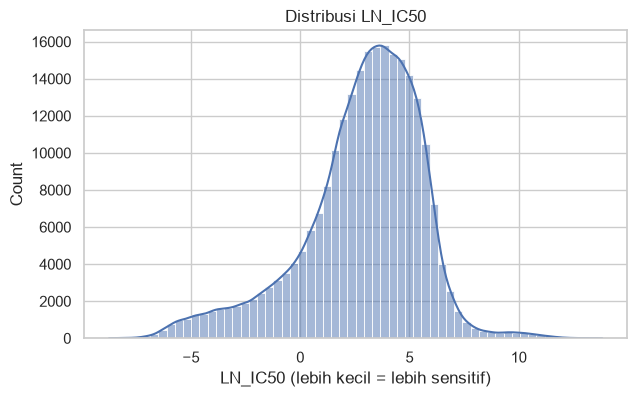

11542


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(gdsc["LN_IC50"], bins=60, kde=True, ax=ax)
ax.set_title("Distribusi LN_IC50")
ax.set_xlabel("LN_IC50 (lebih kecil = lebih sensitif)")
plt.show()              # 11.542

**Temuan, Bukti, Interpretasi, Implikasi**
| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| Sebaran berpuncak di sekitar 3 sampai 4 dan miring ke kiri | Mean 2,82 < median 3,24; skewness (angka kemiringan) -0,81; ekor (nilai min) memanjang sampai -8,75 | Kebanyakan pasangan *cell line*-obat cukup resisten, sedangkan sebagian kecil sangat sensitif dan menarik rata-rata turun. | Pakai median dan kuartil untuk gambaran tipikal; tentukan kelompok sensitif/resisten dengan kuartil |
| Ada nilai ekstrem di kedua sisi, termasuk tonjolan kecil di sekitar 10 | 11.542 baris di luar batas IQR(-3,28 sampai 9,49): 10.137 di bawah dan 1.405 di atas | Nilai ekstrem bukan kesalahan; menggambarkan respons yang sangat sensitif atau sangat resisten | Jangan dibuang; analisis sebaiknya dilakukan per obat

### Grafik Boxplot `LN_IC50` per jaringan

melihat apakah karakter biologis sel berkaitan dengan respon obat. jaringan diurutkan berdasaarkan median agar peringkat mudah dibaca.

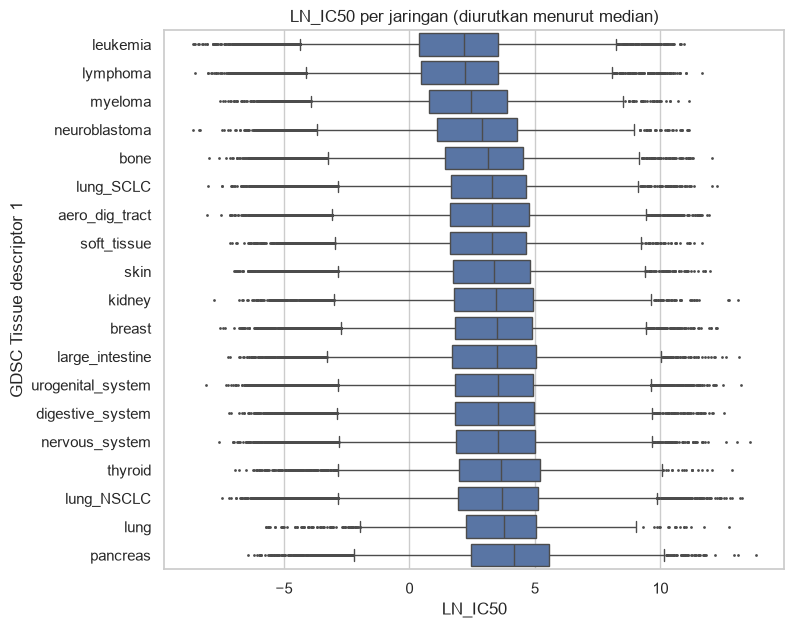

In [ ]:
urutan = gdsc.groupby("GDSC Tissue descriptor 1")["LN_IC50"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 7))
sns.boxplot(data=gdsc, y="GDSC Tissue descriptor 1", x="LN_IC50",
            order=urutan, fliersize=1, ax=ax)
ax.set_title("LN_IC50 per jaringan (diurutkan menurut median)")
plt.show()

**Temuan, Bukti, Interpretasi, Implikasi**
| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| Jaringan darah/limfoid cenderung lebih sensitif | median terendah leukimia 2,16, lymphoma 2,21, myeloma 2,47; tertinggi: pancreas 4,16, lung 3,77, lung_NSCLC 3,69 | Sel leukemia dan limfoma rata-rata merespons obat pada dosis lebih rendah | Mendukung gagasan memakai leukemia/hematopoietik sebagai kelompok pembanding atau fokus lanjutan |
| perbedaan antar jaringan **kecil dibanding sebaran di dalamnya** | Selisih median tertinggi dan terendah 2,0 lebih kecil dari std total 2,76; kotak saling tumpang tindih | jaringan hanya menjelaskan sebagian variasi respons | jaringan belum cukup memisakan respons; analisis perlu dilakukan per obat |
| Semua jaringan punya banyak outlier di kedua sisi | Titik di luar kumis pada setiap jaringan | Ada obat-obat yang sangat efektif atau tidak efektif pada banyak jaringan | Outlier dipertahankan karena bermakna biologis |

### Grafik Bar chart jumlah ***cell_line*** per jaringan 
yang dihitung pada grafik ini adalah `cell_line` (satu baris per ***cell line***), bukan `gdsc`, supaya yang terhitung adalah sel unik, bukan pasangan sel-obat

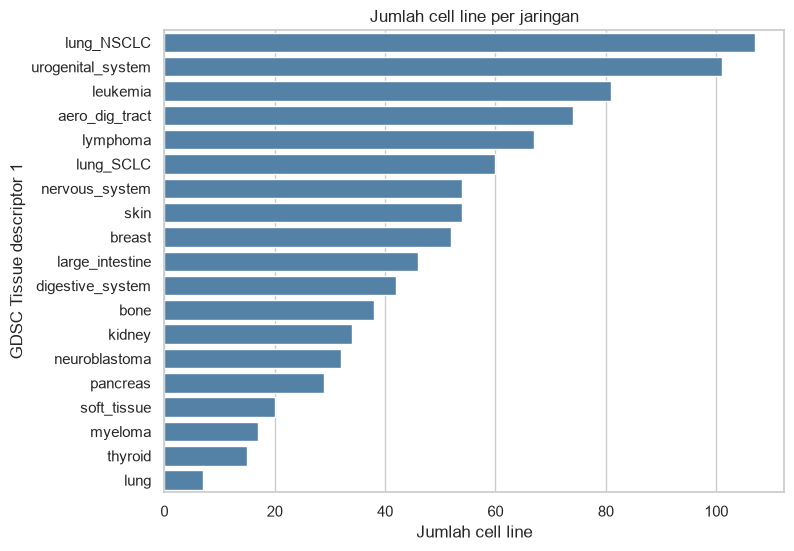

In [16]:
cnt = cell_line["GDSC Tissue descriptor 1"].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=cnt.values, y=cnt.index, ax=ax, color="steelblue")
ax.set_title("Jumlah cell line per jaringan")
ax.set_xlabel("Jumlah cell line")
plt.show()

**Temuan, Bukti, Interpretasi, Implikasi**

| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| Jumlah sampel antar jaringan **cukup timpang** | Terbanyak: lung_NSCLC 107, urogenital_system 101, leukemia 81; tersedikit: lung 7, thyroid 15, myeloma 17 (selisih sekitar 15 kali lipat) | Kelompok kecil tidak cukup kuat untuk kesimpulan statistik | Hati-hati menafsirkan kelompok kecil; pertimbangkan menggabungkan kategori yang tumpang tindih (`lung` dengan `lung_NSCLC` dan `lung_SCLC`, perlu dicek) |
| Sampel leukemia memadai untuk analisis lanjutan | leukemia 81 *cell line*, lymphoma 67 | Cukup untuk PCA/UMAP pada subset hematopoietik, meski terbatas | Analisis fokus leukemia layak dijadikan analisis lanjutan |
| Sebagian *cell line* tidak punya keterangan jaringan | 39 *cell line* tidak tampil di grafik | Grafik tidak mencakup seluruh 969 *cell line* | Tandai sebagai `Unknown` pada tahap preprocessing |

### Grafik Scatter plot `LN_IC50` VS `AUC`

dengan dua kolom ini `LN_IC50` VS `AUC` mengukur sensitivitas dengan cara berbeda, apakah keduanya menceritakan hal yang sama.Dipakai sampel acak 20.000 baris agar grafik tidak terlalu padat dan berat, dan titik dibuat transparan agar area yang padat terlihat.

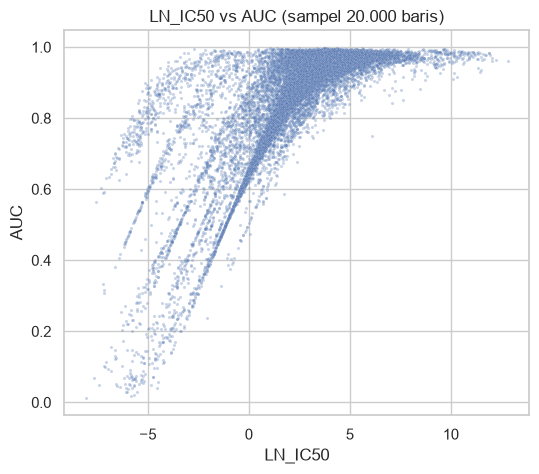

In [17]:
s = gdsc.sample(20000, random_state=42)             # sampel supaya grafik tidak berat
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=s, x="LN_IC50", y="AUC", s=5, alpha=0.3, ax=ax)
ax.set_title("LN_IC50 vs AUC (sampel 20.000 baris)")
plt.show()

**Temuan, Bukti, Interpretasi, Implikasi**

| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| Hubungan **positif tetapi melengkung**, bukan garis lurus | Titik naik dari kiri bawah lalu mendatar mendekati 1; korelasi 0,76 | Makin resisten (LN_IC50 besar), AUC makin besar, tetapi AUC tidak bisa melebihi sekitar 1 | Hubungan tidak linear |
| `AUC` **jenuh di dekat 1** untuk sel resisten | 64,8% baris punya AUC > 0,9; hanya 3,4% yang AUC < 0,5 | `AUC` kurang membedakan antar sel resisten, sedangkan `LN_IC50` tetap menyebar | Pakai `LN_IC50` sebagai variabel respons utama dan `AUC` sebagai pendukung |

### Grafik Heatmap kolerasi variabel numerik

Heatmap meringkas semua hubungan antar variabel dalam satu tabel berwarna.

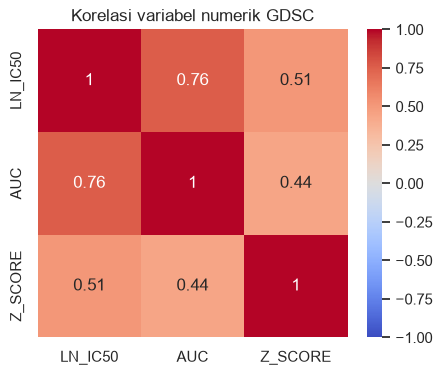

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(gdsc[["LN_IC50", "AUC", "Z_SCORE"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Korelasi variabel numerik GDSC")
plt.show()

**Temuan, Bukti, Interpretasi, Implikasi**

| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| Ketiga variabel berkorelasi **positif sedang sampai kuat** | `LN_IC50`–`AUC` 0,76; `LN_IC50`–`Z_SCORE` 0,51; `AUC`–`Z_SCORE` 0,44 | Ketiganya mengukur sensitivitas dari sudut berbeda; `Z_SCORE` lebih rendah karena sudah distandarkan per obat | Tidak ada pasangan yang hampir identik (> 0,9), jadi tidak ada redundansi ekstrem |
| Korelasi 0,76 kemungkinan meremehkan hubungan sebenarnya | Scatter plot menunjukkan hubungan melengkung, sedangkan korelasi ini mengukur hubungan lurus | Hubungan sebenarnya lebih kuat daripada angka yang tampil | Bila `AUC` dan `LN_IC50` dipakai bersamaan nanti, perhatikan tumpang tindih informasinya |

### Grafik Histogram TPM sebelum dan sesudah `log2(TPM+1)`

grafik ini berguna untuk bukti keputusan transformasi di rencana preprocessing. Dua histogram disandingkan agar sebelum dan sesudah log bisa dibandingkan langsung.Dipakai sampel acak 500.000 nilai dari 100 sampel, karena seluruh matriks berisi sekitar 59 juta nilai.

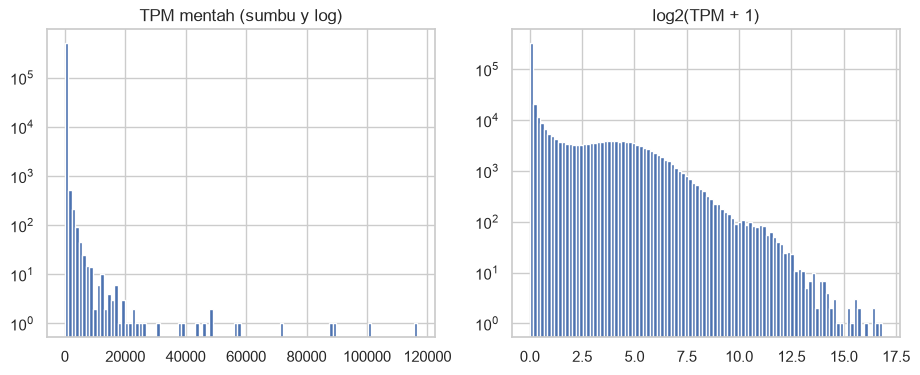

Persentase nilai 0: 54.2 %


In [19]:
kol = rng.choice(expr.columns, size=100, replace=False)
nilai = expr[kol].to_numpy().ravel()
nilai = rng.choice(nilai, size=500_000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(nilai, bins=100, log=True);                axes[0].set_title("TPM mentah (sumbu y log)")
axes[1].hist(np.log2(nilai + 1), bins=100, log=True);   axes[1].set_title("log2(TPM + 1)")
plt.show()
print("Persentase nilai 0:", round(100 * (nilai == 0).mean(), 1), "%")

**Temuan, Bukti, Interpretasi, Implikasi**

| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| TPM mentah **sangat miring**: hampir semua nilai menumpuk di dekat 0 dan ada ekor sangat panjang | Panel kiri: nilai mencapai lebih dari 100.000, sedangkan mayoritas mendekati 0 | Sedikit nilai ekstrem akan mendominasi perhitungan jarak dan PCA | Terapkan `log2(TPM+1)` sebelum reduksi dimensi |
| Setelah log, skala menjadi sekitar 0 sampai 17 dan bentuk sebaran terlihat | Panel kanan: ada tonjolan di sekitar 3 sampai 6 (gen yang aktif) | Transformasi log menekan nilai ekstrem dan menampakkan struktur data | Pakai data log untuk seluruh analisis |
| Data **sarat nilai nol** | 54,2% nilai sampel bernilai 0 | Banyak gen tidak terekspresi pada banyak sampel | Perlu filter gen yang tidak aktif |

### Grafik Histogram proporsi sampel aktif per gen

** gen dianggap **aktif** pada suatu sampel bila TPM-nya lebih dari 1. Untuk tiap gen dihitung proporsi sampel tempat ia aktif (0 berarti tidak pernah aktif, 1 berarti aktif di semua sampel), lalu sebarannya digambar dengan histogram.

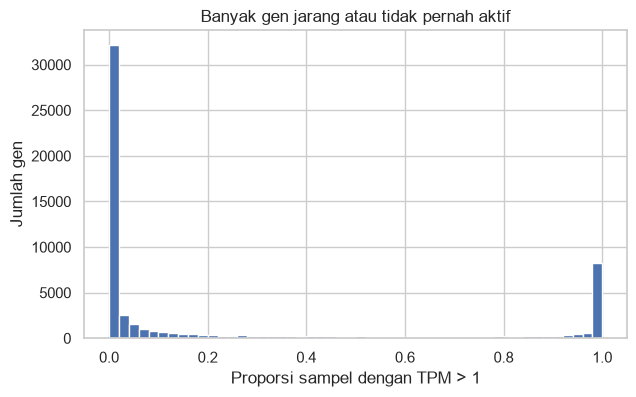

In [20]:
gen_aktif = (expr > 1).mean(axis=1)     # proporsi sampel dengan TPM > 1 untuk tiap gen
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gen_aktif, bins=50)
ax.set_xlabel("Proporsi sampel dengan TPM > 1"); ax.set_ylabel("Jumlah gen")
ax.set_title("Banyak gen jarang atau tidak pernah aktif")
plt.show()

**Temuan, Bukti, Interpretasi, Implikasi**

| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| Grafik berbentuk **dua tumpukan**: satu di dekat 0 dan satu di dekat 1 | Sekitar 35.495 gen (61%) aktif di kurang dari 5% sampel, termasuk 18.737 gen yang tidak pernah aktif; 9.051 gen aktif di minimal 95% sampel | Sebagian besar gen hampir tidak aktif, dan gen yang aktif di semua sampel tidak membedakan sampel | Gen paling berguna adalah yang aktif hanya di sebagian sampel |
| Jumlah gen yang layak dipertahankan jauh lebih kecil dari total | 19.809 gen aktif di minimal 10% sampel, dari 57.820 gen | Dimensi bisa dikurangi tanpa kehilangan informasi penting | Filter gen (TPM > 1 pada minimal 10% sampel), lalu pilih gen paling bervariasi |

### Grafik Boxplot `log2(TPM + 1)` antar sampel

Boxplot per sampel dipilih untuk membandingkan **median, sebaran, dan *outlier*** tiap sampel berdampingan.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7316\1482671384.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([c.split("_")[0] for c in kol], rotation=90)


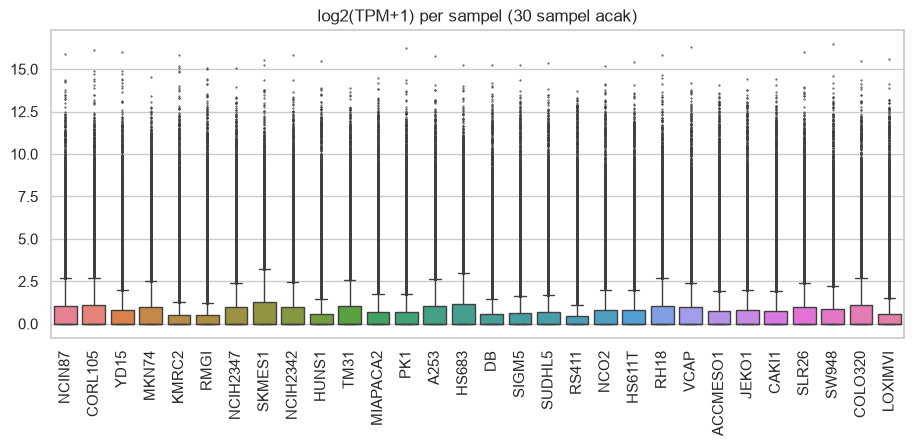

In [21]:
kol = rng.choice(expr.columns, size=30, replace=False)
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=np.log2(expr[kol] + 1), ax=ax, fliersize=0.5)
ax.set_xticklabels([c.split("_")[0] for c in kol], rotation=90)
ax.set_title("log2(TPM+1) per sampel (30 sampel acak)")
plt.show()

**Temuan, Bukti, Interpretasi, Implikasi**

| Temuan | Bukti | Interpretasi | Implikasi |
|---|---|---|---|
| Kotak-kotak antar sampel **seragam** | Median log2 TPM tiap sampel hanya berkisar 0 sampai 0,07; tidak ada sampel yang menyimpang jauh | Sampel sebanding, sejalan dengan total TPM yang hampir sama (sekitar 1 juta) dan jumlah gen aktif yang mirip | Tidak perlu membuang sampel atau normalisasi antar-sampel tambahan |
| Kotak tampak pipih di dekat 0 dengan banyak titik di atas | Median per sampel 54,2% nilai bernilai 0; titik *outlier* sampai sekitar 16 sampai 17 | Banyak gen tidak aktif, dan sedikit gen sangat aktif | Fokus preprocessing pada filter gen dan standardisasi per gen sebelum PCA |